### in a polinomial equation y = 5x^3 - 10x^2 - 20x + 10

In [1]:
# importing necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras import metrics
from tensorflow.keras.losses import MeanSquaredError

2026-06-19 16:02:38.597687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Polynomial function
def polynomial(x):
    return 5 * x**3 - 10 * x**2 - 20 * x + 10

In [3]:
# Generate data
np.random.seed(4)
x = np.random.uniform(-20, 20, 1000)
y = polynomial(x)

In [4]:
# Normalize to [-1, 1]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
y_norm = 2 * (y - y_min) / (y_max - y_min) - 1

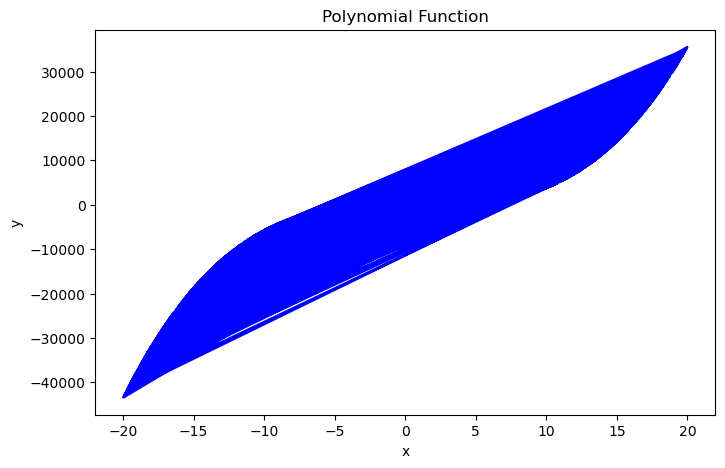

In [16]:
# simple plot this polinomial value
plt.figure(figsize=(8,5))
plt.plot(x, y, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

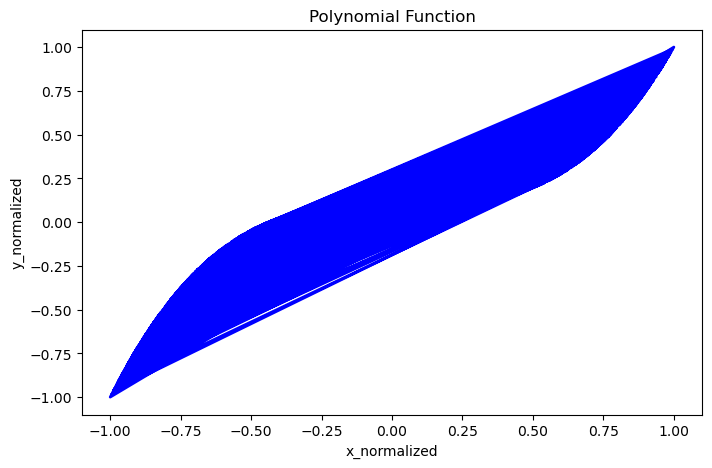

In [17]:
plt.figure(figsize=(8,5))
plt.plot(x_norm, y_norm, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x_normalized")
plt.ylabel("y_normalized")
plt.show()

In [5]:
# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = x_norm[:800], x_norm[800:], y_norm[:800], y_norm[800:]

In [6]:
X_train.shape

(800,)

In [7]:
# Reshape
X_train= X_train.reshape(-1, 1)
y_train= y_train.reshape(-1, 1)

X_test= X_test.reshape(-1, 1)
y_test= y_test.reshape(-1, 1)

In [8]:
# Build model
model = tf.keras.Sequential([
    Input(shape=(1,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])


In [9]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [10]:
# Train
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0711 - val_loss: 0.0363
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0274 - val_loss: 0.0194
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - val_loss: 0.0110
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 - val_loss: 0.0071
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0047
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0036
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - val_loss: 9.0382e-04
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5787e-04 - val_loss: 6.9774e-04
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1731e-04 - v

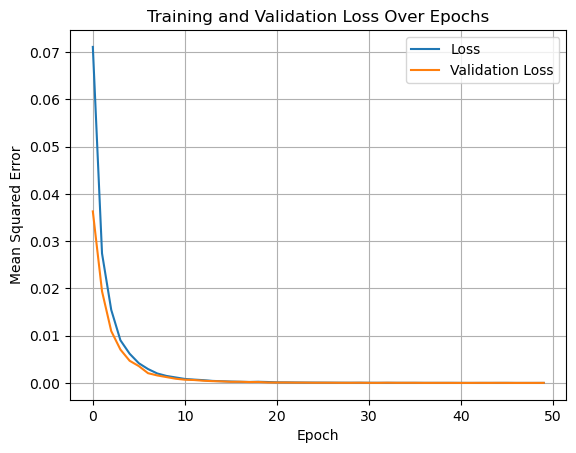

In [11]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Training and Validation Loss Over Epochs')
plt.grid(True)
plt.show()

In [14]:
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Final Mean Squared Error on Test Set: {test_loss:.6f}')

Final Mean Squared Error on Test Set: 0.000025


In [15]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score on Test Set: {r2:.6f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
R2 Score on Test Set: 0.999819
